In [1]:
# standard imports
import pandas as pd
import numpy as np

# Do not change this option; This allows the CodeGrade auto grading to function correctly
pd.set_option('display.max_columns', 20)

In [3]:
import pandas as pd

apartments = pd.read_csv('apartments_for_rent.csv')

In [4]:
# check basic info about dataset
apartments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            10000 non-null  int64  
 1   latitude      10000 non-null  float64
 2   longitude     10000 non-null  float64
 3   bathrooms     9967 non-null   float64
 4   bedrooms      9994 non-null   float64
 5   fee           10000 non-null  object 
 6   has_photo     10000 non-null  object 
 7   pets_allowed  5837 non-null   object 
 8   square_feet   10000 non-null  int64  
 9   price         10000 non-null  int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 781.4+ KB


In [5]:
# The "id" column contains information that is not pertinent to our current task.
apartments['id'].head()

0    5668626895
1    5664597177
2    5668626833
3    5659918074
4    5668626759
Name: id, dtype: int64

In [6]:
# the "fee" column exhibits uniform values across all instances within the dataset.
apartments['fee'].value_counts()

fee
No    10000
Name: count, dtype: int64

In [7]:
apartments = apartments.drop(['id', 'fee'], axis=1)

In [8]:
from sklearn.model_selection import train_test_split

# 1. Save the target variable
price_target = apartments['price']

# 2. Create the features DataFrame
apartments_features = apartments.drop('price', axis=1)

# 3. Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    apartments_features,
    price_target,
    test_size=0.2,
    random_state=42
)

In [9]:
# check descriptive statistics
X_train.describe()

,latitude,longitude,bathrooms,bedrooms,square_feet
count,8000.000000,8000.000000,7974.000000,7994.000000,8000.000000
mean,37.638087,-94.763954,1.382242,1.750188,945.434500
std,5.523883,15.818233,0.612889,0.950951,532.799944
min,21.315500,-158.022100,1.000000,0.000000,106.000000
25%,33.595300,-101.858700,1.000000,1.000000,650.000000
50%,38.648700,-93.737500,1.000000,2.000000,804.000000
75%,41.271500,-82.383300,2.000000,2.000000,1100.000000
max,61.594000,-70.191600,8.000000,9.000000,11318.000000


Matplotlib is building the font cache; this may take a moment.


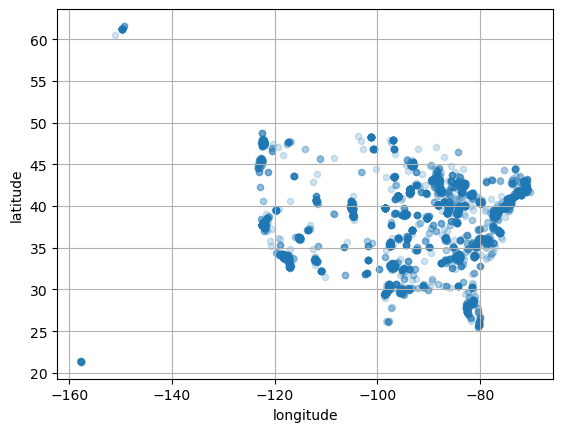

In [10]:
import matplotlib.pyplot as plt

# create scatterplot of all rentals
X_train.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()

In [11]:
#  check value count percentages for "pets_allowed" feature
X_train['pets_allowed'].value_counts(normalize=True)

pets_allowed
Cats,Dogs    0.897220
Cats         0.080586
Dogs         0.022193
Name: proportion, dtype: float64

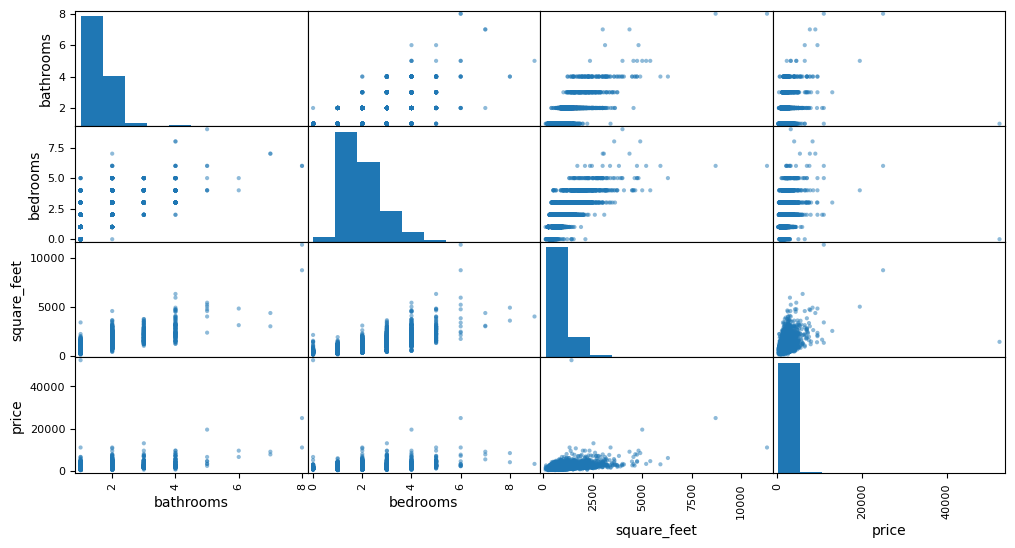

In [12]:
# plot select numeric values
from pandas.plotting import scatter_matrix

# select only a few numeric attributes from the training data
col_attributes = ['bathrooms','bedrooms','square_feet']

# combine training features and target into DataFrame
combined_df = pd.concat([X_train[col_attributes], y_train], axis=1)

# plots scatterplots and histograms when variable is compared against itself
scatter_matrix(combined_df, figsize=(12, 6))
plt.show()

In [13]:
# select attributes
col_attributes_2 = ['latitude','longitude','bathrooms','bedrooms','square_feet']

# create new combined DataFrame that includes longitude and latitude
combined_df_2 = pd.concat([X_train[col_attributes_2], y_train], axis=1)

# check correlations
corr_matrix = combined_df_2.corr()
corr_matrix["price"].sort_values(ascending=False)

price          1.000000
square_feet    0.456036
bathrooms      0.394160
bedrooms       0.298313
latitude       0.017938
longitude     -0.181943
Name: price, dtype: float64

In [14]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

In [15]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = make_pipeline(
    SimpleImputer(strategy='constant', fill_value='No_Pets'),
    OneHotEncoder(drop='first')
)

In [16]:
from sklearn.compose import ColumnTransformer

# 1. Numerical and categorical column lists
num_attributes = ['latitude', 'longitude', 'bathrooms', 'bedrooms', 'square_feet']
cat_attributes = ['has_photo', 'pets_allowed']

# 2. Create the ColumnTransformer
preprocessing = ColumnTransformer([
    ('num', num_pipeline, num_attributes),
    ('cat', cat_pipeline, cat_attributes)
])

# 3. Fit and transform the training data
X_train_prepared = preprocessing.fit_transform(X_train)

In [17]:
from sklearn.linear_model import LinearRegression

# 1. Create the model
lin_reg = LinearRegression()

# 2. Fit the model to the training data
lin_reg.fit(X_train_prepared, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
# perform a 10-fold cross validation using the `lin_reg` model

from sklearn.model_selection import cross_val_score

lin_reg_rmses = -cross_val_score(lin_reg, X_train_prepared, y_train,
                              scoring="neg_root_mean_squared_error", cv=10)

In [19]:
pd.Series(lin_reg_rmses).describe()

count      10.000000
mean      889.858340
std       376.497817
min       656.297734
25%       703.231636
50%       752.891579
75%       904.683403
max      1920.415202
dtype: float64

In [20]:
from sklearn.ensemble import RandomForestRegressor

# instantiate a RandomForestRegressor class
forest_reg = RandomForestRegressor(random_state=42) 

# fit the model
forest_reg.fit(X_train_prepared, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
# cross validation
forest_rmses = -cross_val_score(forest_reg, X_train_prepared, y_train,
                                scoring="neg_root_mean_squared_error", cv=10)

# check cross validation scores
pd.Series(forest_rmses).describe()

count      10.000000
mean      692.806541
std       414.544265
min       399.456773
25%       504.282052
50%       595.845346
75%       652.569025
max      1837.508391
dtype: float64

In [23]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Predict
final_predictions = forest_reg.predict(X_test_prepared)

# Compute RMSE manually
mse = mean_squared_error(y_test, final_predictions)
final_rmse = round(np.sqrt(mse), 2)

print(final_rmse)

464.09
